In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [27]:
# load the dataset

df=pd.read_csv('insurance.csv')

In [28]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [29]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [30]:
# data preprocessing

df_encoded = pd.get_dummies(df, drop_first=True)

In [31]:
X = df_encoded.drop(columns=['charges'])
y = df_encoded['charges']

In [32]:
# Split into 80% training and 20% testing

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [33]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [34]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [35]:
# ANN Architecture

model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1) 
])

C:\Users\Thor fin\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [36]:
# Compile and train

model.compile(optimizer='adam', loss='mae', metrics=['mae'])

In [37]:
history = model.fit(
    X_train_scaled, y_train, 
    validation_split=0.2, 
    epochs=100, 
    batch_size=32, 
    verbose=0 
)

In [38]:
# Evaluate

y_pred = model.predict(X_test_scaled).flatten()

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


In [39]:
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [40]:
print(f"Mean Absolute Error (MAE): ${mae:.2f}")
print(f"R² Score (Accuracy Metric): {r2 * 100:.2f}%")

Mean Absolute Error (MAE): $3167.28
R² Score (Accuracy Metric): 74.54%


In [41]:
model.save('insurance_charges_model.keras')

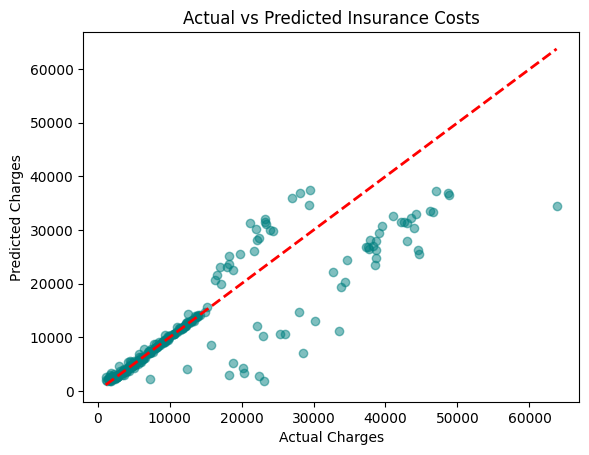

In [42]:
# Plot to visualize predictions vs real values

plt.scatter(y_test, y_pred, alpha=0.5, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.title('Actual vs Predicted Insurance Costs')
plt.show()